In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
from melody import build_rolls, pad_rolls, compute_highest_per_instrument, track_lead_voice

NAZWA_PLIKU     = 'music/Age_of_Empires_2_Menu_Music.mid'
FS              = 100   # frames per second
MIN_NOTES       = 10    # minimum notes to keep an instrument
MIN_PITCH       = 48    # ignore pitches below C3
MIN_ENERGY_PER_FRAME = 10
SWITCH_N        = 3     # beats a challenger must lead to trigger a switch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
utwor = pretty_midi.PrettyMIDI(NAZWA_PLIKU)

beats = utwor.get_beats()
beat_frames = (beats * FS).astype(int)
print(f"Tempo: {60 / np.mean(np.diff(beats)):.1f} BPM średnio, {len(beats)} beatów")

rolls, instruments = build_rolls(utwor, fs=FS, min_notes=MIN_NOTES)
print(f"Zachowano {len(instruments)} instrumentów")

Tempo: 131.0 BPM średnio, 133 beatów
Zachowano 13 instrumentów


In [4]:
padded, max_len = pad_rolls(rolls)
beat_frames_clipped = np.clip(beat_frames, 0, max_len)
n_windows = len(beat_frames_clipped) - 1
n_inst = len(padded)
print(f"{n_windows} beatów, {n_inst} instrumentów")

132 beatów, 13 instrumentów


In [5]:
highest = compute_highest_per_instrument(padded, beat_frames_clipped, MIN_PITCH, MIN_ENERGY_PER_FRAME)
lead_inst_idx, lead_pitch = track_lead_voice(highest, n_windows, n_inst, SWITCH_N)
print(f"Tracker gotowy — pierwsze 10 pitchy: {lead_pitch[:10]}")

Tracker gotowy — pierwsze 10 pitchy: [93, 93, 93, 93, 69, 69, 69, 69, 69, 69]


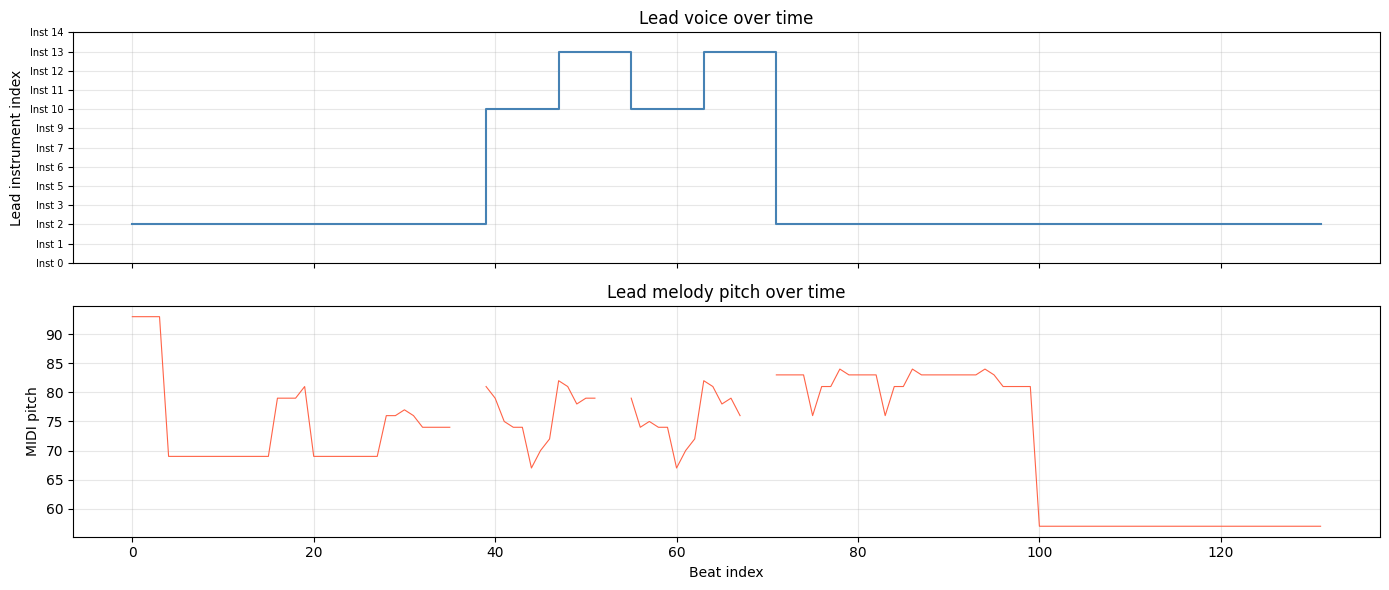

In [11]:
# Visualize which instrument leads over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: lead instrument index
axes[0].plot(lead_inst_idx, drawstyle='steps-post', color='steelblue')
axes[0].set_ylabel('Lead instrument index')
axes[0].set_yticks(range(n_inst))
axes[0].set_yticklabels([f'Inst {instruments[i][0]}' for i in range(n_inst)], fontsize=7)
axes[0].set_title('Lead voice over time')
axes[0].grid(True, alpha=0.3)

# Bottom: lead pitch value
pitch_vals = [p if p is not None else np.nan for p in lead_pitch]
axes[1].plot(pitch_vals, color='tomato', linewidth=0.8)
axes[1].set_ylabel('MIDI pitch')
axes[1].set_xlabel('Beat index')
# show as notes
axes[1].set_title('Lead melody pitch over time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Summary: how many beats each instrument led
from collections import Counter

counts = Counter(lead_inst_idx.tolist())
print("Udział w prowadzeniu (beaty):")
for inst_idx, count in sorted(counts.items(), key=lambda x: -x[1]):
    orig_idx, inst = instruments[inst_idx]
    name = f'Instrument {orig_idx}'
    print(f"  {name}: {count} beatów ({100*count/n_windows:.1f}%)")

print(f"\nSekwencja lead_pitch gotowa do dalszej analizy: {len([p for p in lead_pitch if p is not None])} aktywnych beatów")

Udział w prowadzeniu (beaty):
  Instrument 2: 100 beatów (75.8%)
  Instrument 10: 16 beatów (12.1%)
  Instrument 13: 16 beatów (12.1%)

Sekwencja lead_pitch gotowa do dalszej analizy: 123 aktywnych beatów
